In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.metrics import mean_squared_error as MSE
from scipy.stats import gaussian_kde

In [2]:
# Load the dataset
Cars_df = pd.read_csv('Validation.csv')

In [3]:
# Drop rows with any missing values
data_frame = Cars_df.dropna()

In [4]:
data_frame = pd.read_csv('Validation.csv')

def convert_price_to_number(price_str):
    # Remove commas and convert to float
    return float(price_str.replace(',', ''))

# Apply the function to the 'Price' column
data_frame['Price'] = data_frame['Price'].apply(convert_price_to_number)
# Applying log transformation to the 'Price' column to reduce skewness
data_frame['Log_Price'] = np.log1p(data_frame['Price'])

filtered_file_path = 'Validation_Filtered.csv'
data_frame.to_csv(filtered_file_path, index=False)

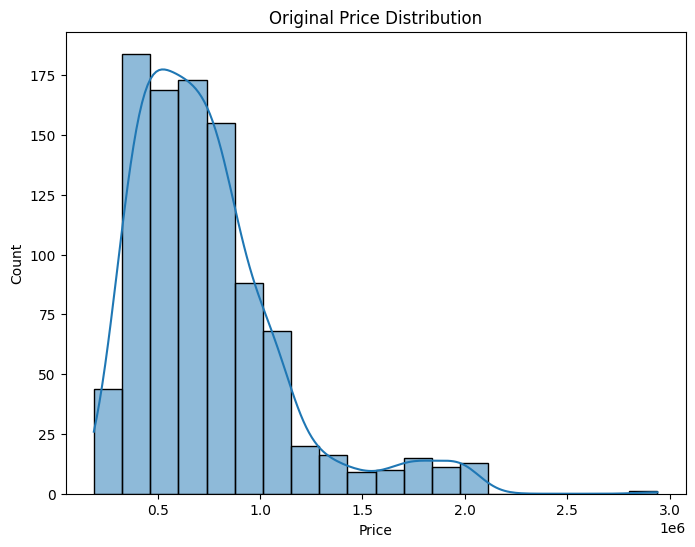

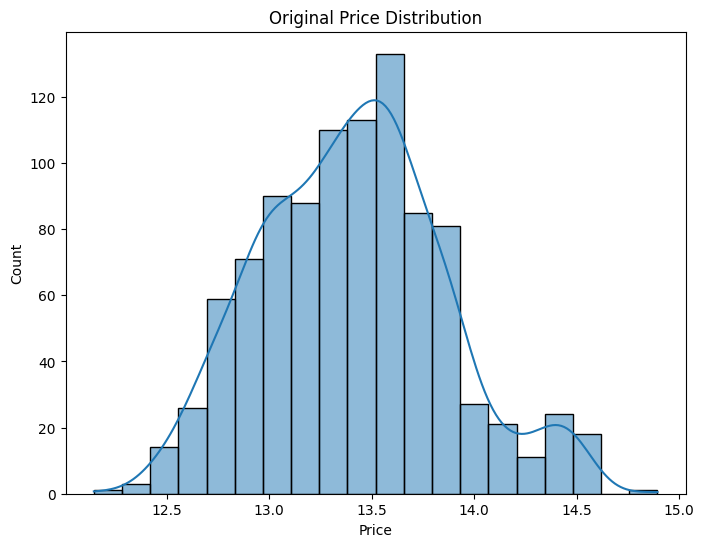

In [5]:
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Price'], bins=20, kde=True)
plt.title('Original Price Distribution')
plt.xlabel('Price')

plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Log_Price'], bins=20, kde=True)
plt.title('Original Price Distribution')
plt.xlabel('Price')


plt.show()

In [6]:
label_encoder = LabelEncoder()

data_frame['Transmission ID'] = label_encoder.fit_transform(data_frame['Transmission'])
Transmission = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [7]:
data_frame['Power'] = data_frame['Max Power']
# Convert the attribute to a numeric type
data_frame['Power'] = pd.to_numeric(data_frame['Power'], errors='coerce')

In [8]:
data_frame['Price'] = pd.to_numeric(data_frame['Price'], errors='coerce')

In [9]:
Aim_Price = data_frame["Log_Price"]
data_frame = data_frame.drop(["Log_Price"],axis=1)
data_frame["Aim_Price"]= Aim_Price
data_frame.to_csv("Validation_Final.csv")

In [10]:
data_frame = data_frame[['Year','Seating Capacity', 'Transmission ID','Power','Aim_Price']]

In [11]:
X = data_frame[['Year','Seating Capacity', 'Transmission ID','Power']]

In [12]:
y = data_frame['Aim_Price']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

In [14]:
train_dmatrix = xgb.DMatrix(data = X_train, label = y_train)
test_dmatrix = xgb.DMatrix(data = X_test, label = y_test)

In [15]:
param = {"booster":"gblinear", "objective":"reg:squarederror"}

In [16]:
xgb_r = xgb.train(params = param, dtrain = train_dmatrix, num_boost_round = 10)
pred = xgb_r.predict(test_dmatrix )

In [17]:
rmse = np.sqrt(MSE(y_test, pred))
print("RMSE : % f" %(rmse))

RMSE :  0.364153


In [18]:
mse = MSE(y_test, pred)
print("MSE : % f" %(mse))

MSE :  0.132607


In [19]:
r2 = r2_score(y_test, pred)
print("R² score:", r2)

R² score: 0.357086901659984


In [20]:
# Define the parameter grid
param_grid = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

In [21]:
# Initialize the XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror')

In [22]:
# Set up GridSearchCV
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=2)

In [23]:
# Fit GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   1.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   1.3s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.5; total time=   0.2s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.7s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   0.4s
[CV] END colsample_bytree=0.5, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; tot

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             param_grid={'colsample_bytree': [0.5, 0.7, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'min_child_weight': [1, 5, 10],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.5, 0.7, 1.0]},
             scoring='neg_mean_squared_error', verbose=2)

In [24]:
# Best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best parameters found:  {'colsample_bytree': 0.5, 'learning_rate': 0.2, 'max_depth': 4, 'min_child_weight': 10, 'n_estimators': 200, 'subsample': 0.5}
Best score:  -0.015969115731673363


In [25]:
# Use the best estimator to make predictions
predictions = grid_search.best_estimator_.predict(X_test)

In [26]:
rmse = np.sqrt(MSE(y_test, predictions))
print("RMSE : % f" %(rmse))

RMSE :  0.119771


In [27]:
mse = MSE(y_test, predictions)
print("MSE : % f" %(mse))

MSE :  0.014345


In [28]:
r2 = r2_score(y_test, predictions)
print("R² score:", r2)

R² score: 0.9304517008079946


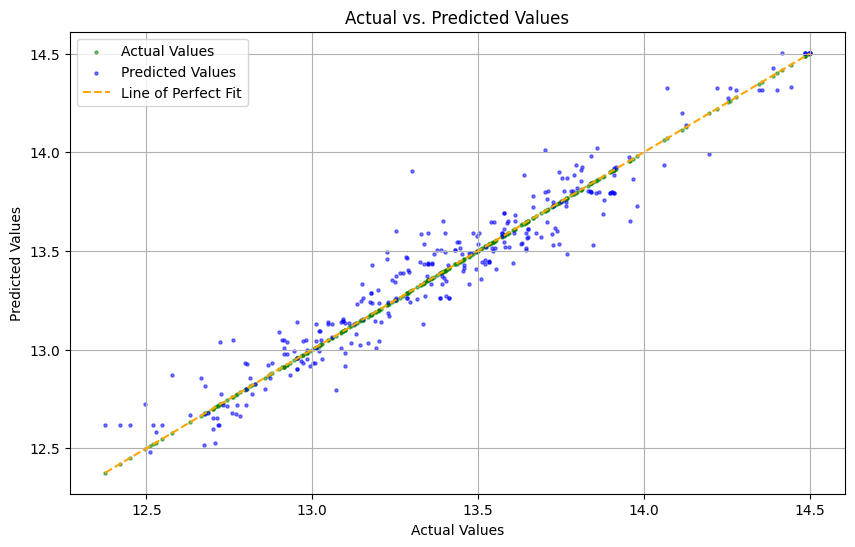

In [29]:
plt.figure(figsize=(10, 6))

# Plot the actual values in green, with smaller circles
plt.scatter(y_test, y_test, color='green', s=5, alpha=0.5, label='Actual Values')  # s is the size of the marker

# Plot the predicted values in blue, with smaller circles
plt.scatter(y_test, predictions, color='blue', s=5, alpha=0.5, label='Predicted Values')  # Same size reduction as actual

# Add an orange line for perfect predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='orange', linestyle='--', label='Line of Perfect Fit')

plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()  # Add a legend to clarify the plot elements
plt.show()


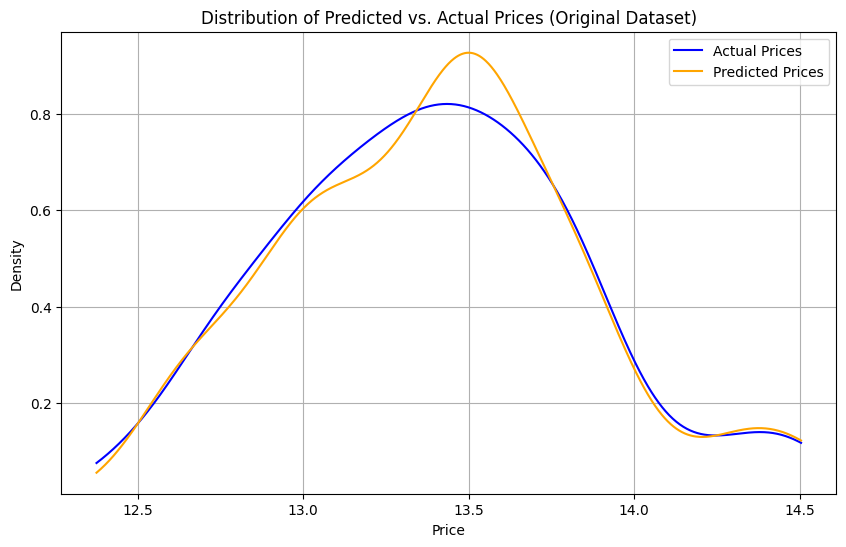

In [30]:
# Set up the figure and axis
plt.figure(figsize=(10, 6))

# Calculate the density using Gaussian Kernel Density Estimation
density_actual = gaussian_kde(y_test)
density_pred = gaussian_kde(predictions)

# Set up a range of values for x
x_vals = np.linspace(min(min(y_test), min(predictions)), max(max(y_test), max(predictions)), 1000)

# Calculate the density values for each range
y_actual = density_actual(x_vals)
y_pred = density_pred(x_vals)

# Plotting the density estimates as lines
plt.plot(x_vals, y_actual, label='Actual Prices', color='blue')
plt.plot(x_vals, y_pred, label='Predicted Prices', color='orange')

# Adding titles and labels
plt.title('Distribution of Predicted vs. Actual Prices (Original Dataset)')
plt.xlabel('Price')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()